In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import*


In [ ]:
df = pd.read_csv("nhs_drug_forecasting_dataset_final.csv")

In [ ]:
df

,ds,unique_id,y
0,2020-11-01,Atorvastatin,705974.0
1,2020-12-01,Atorvastatin,795739.0
2,2021-01-01,Atorvastatin,826006.0
3,2021-02-01,Atorvastatin,748542.0
4,2021-03-01,Atorvastatin,865732.0
...,...,...,...
515,2025-11-01,Venlafaxine,93289.0
516,2025-12-01,Venlafaxine,107230.0
517,2026-01-01,Venlafaxine,108526.0
518,2026-02-01,Venlafaxine,100488.0


In [ ]:
df["ds"] = pd.to_datetime(df["ds"])
df= df.rename(columns={'drug': 'unique_id'})

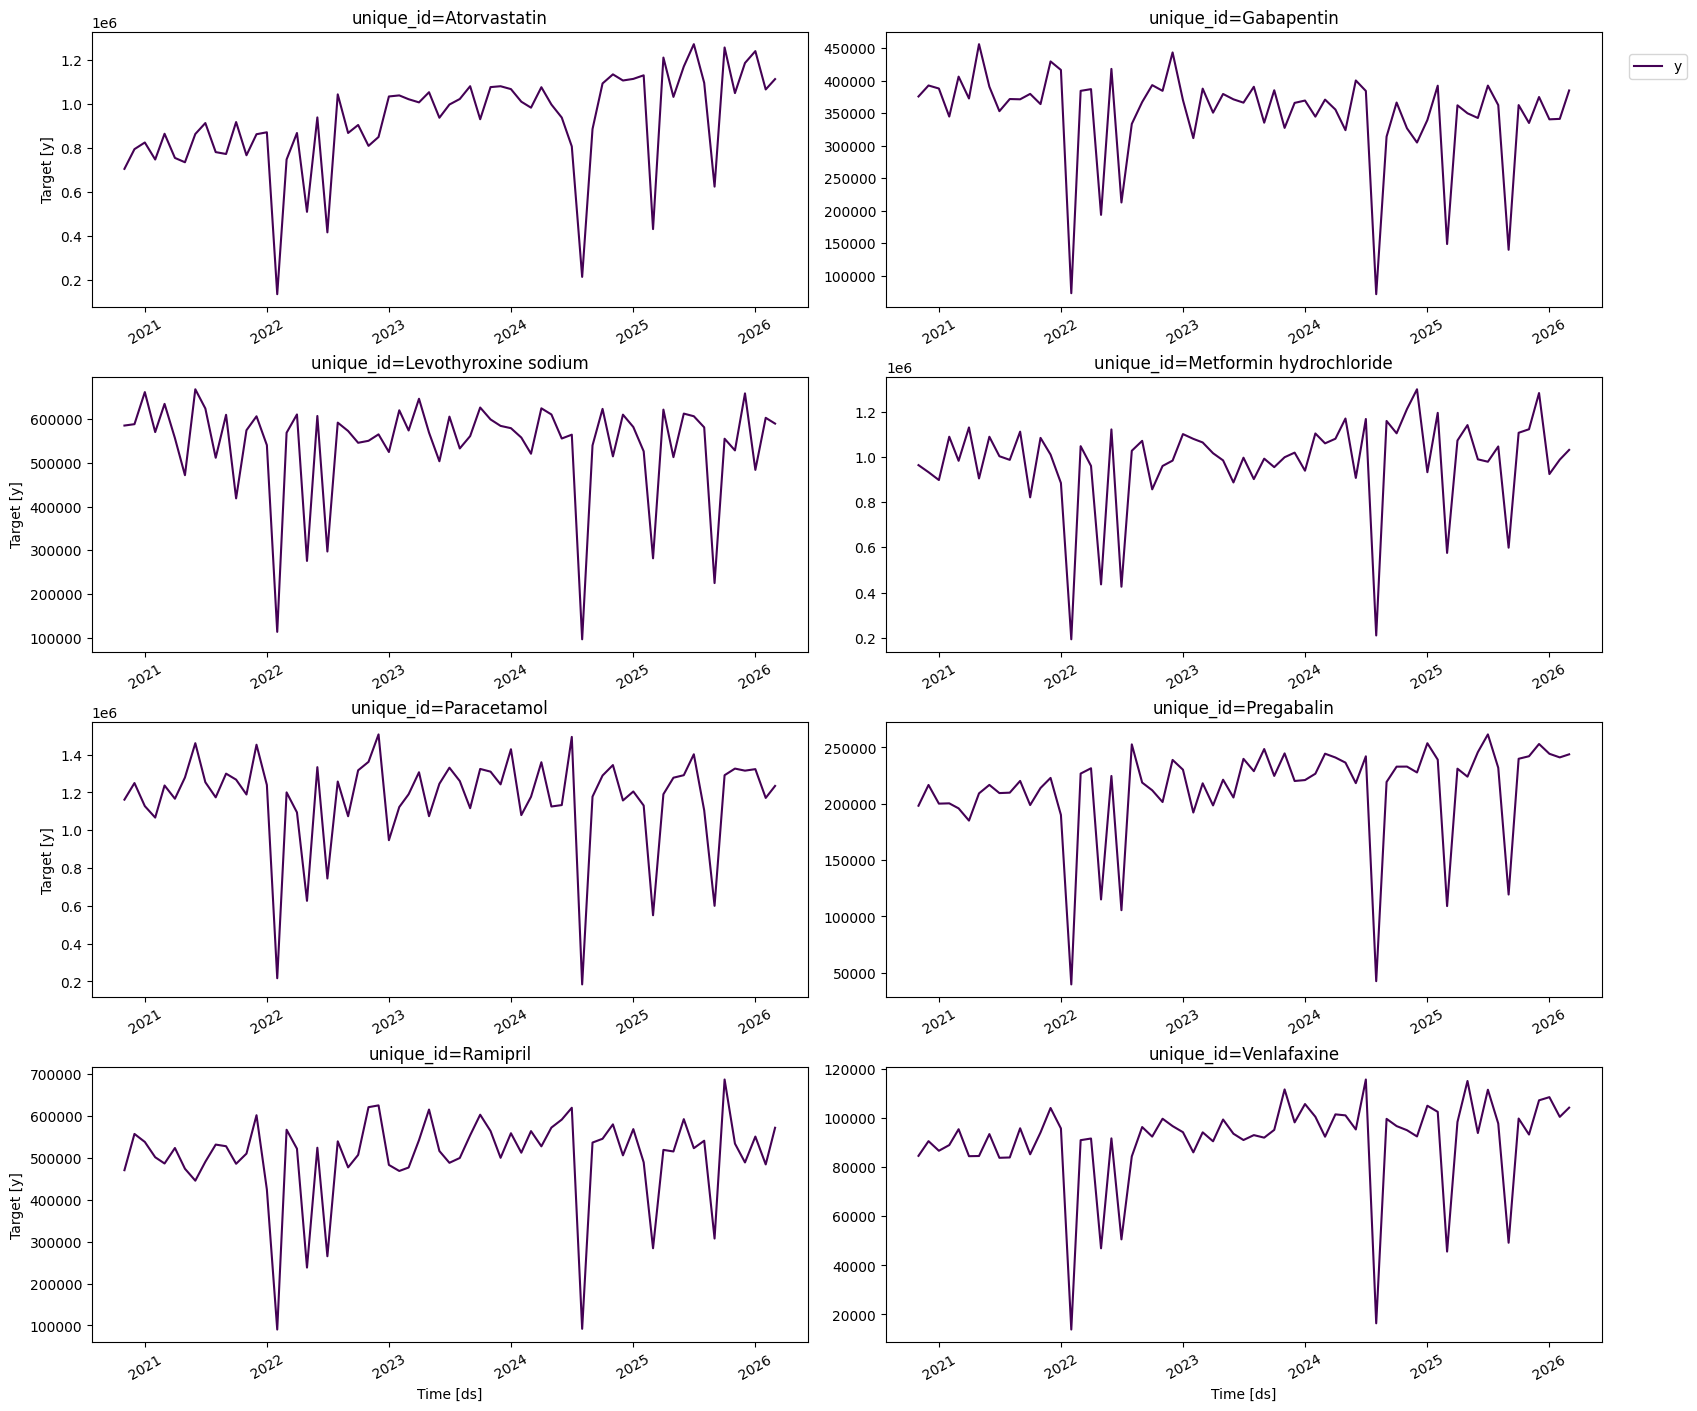

In [ ]:
plot_series(df =df, palette = "viridis")

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    HistoricAverage,
    WindowAverage
)

horizon = 12

models = [
    Naive(),
    SeasonalNaive(season_length=12),
    HistoricAverage(),
    WindowAverage(window_size=12),
]

sf = StatsForecast(
    models=models,
    freq="MS"   # monthly frequency
)

sf.fit(df=df)

preds = sf.predict(h=horizon)

In [ ]:
preds.head()

,unique_id,ds,Naive,SeasonalNaive,HistoricAverage,WindowAverage
0,Atorvastatin,2026-04-01,1114436.0,1212302.0,922040.969231,1111111.75
1,Atorvastatin,2026-05-01,1114436.0,1033431.0,922040.969231,1111111.75
2,Atorvastatin,2026-06-01,1114436.0,1171707.0,922040.969231,1111111.75
3,Atorvastatin,2026-07-01,1114436.0,1273335.0,922040.969231,1111111.75
4,Atorvastatin,2026-08-01,1114436.0,1097261.0,922040.969231,1111111.75


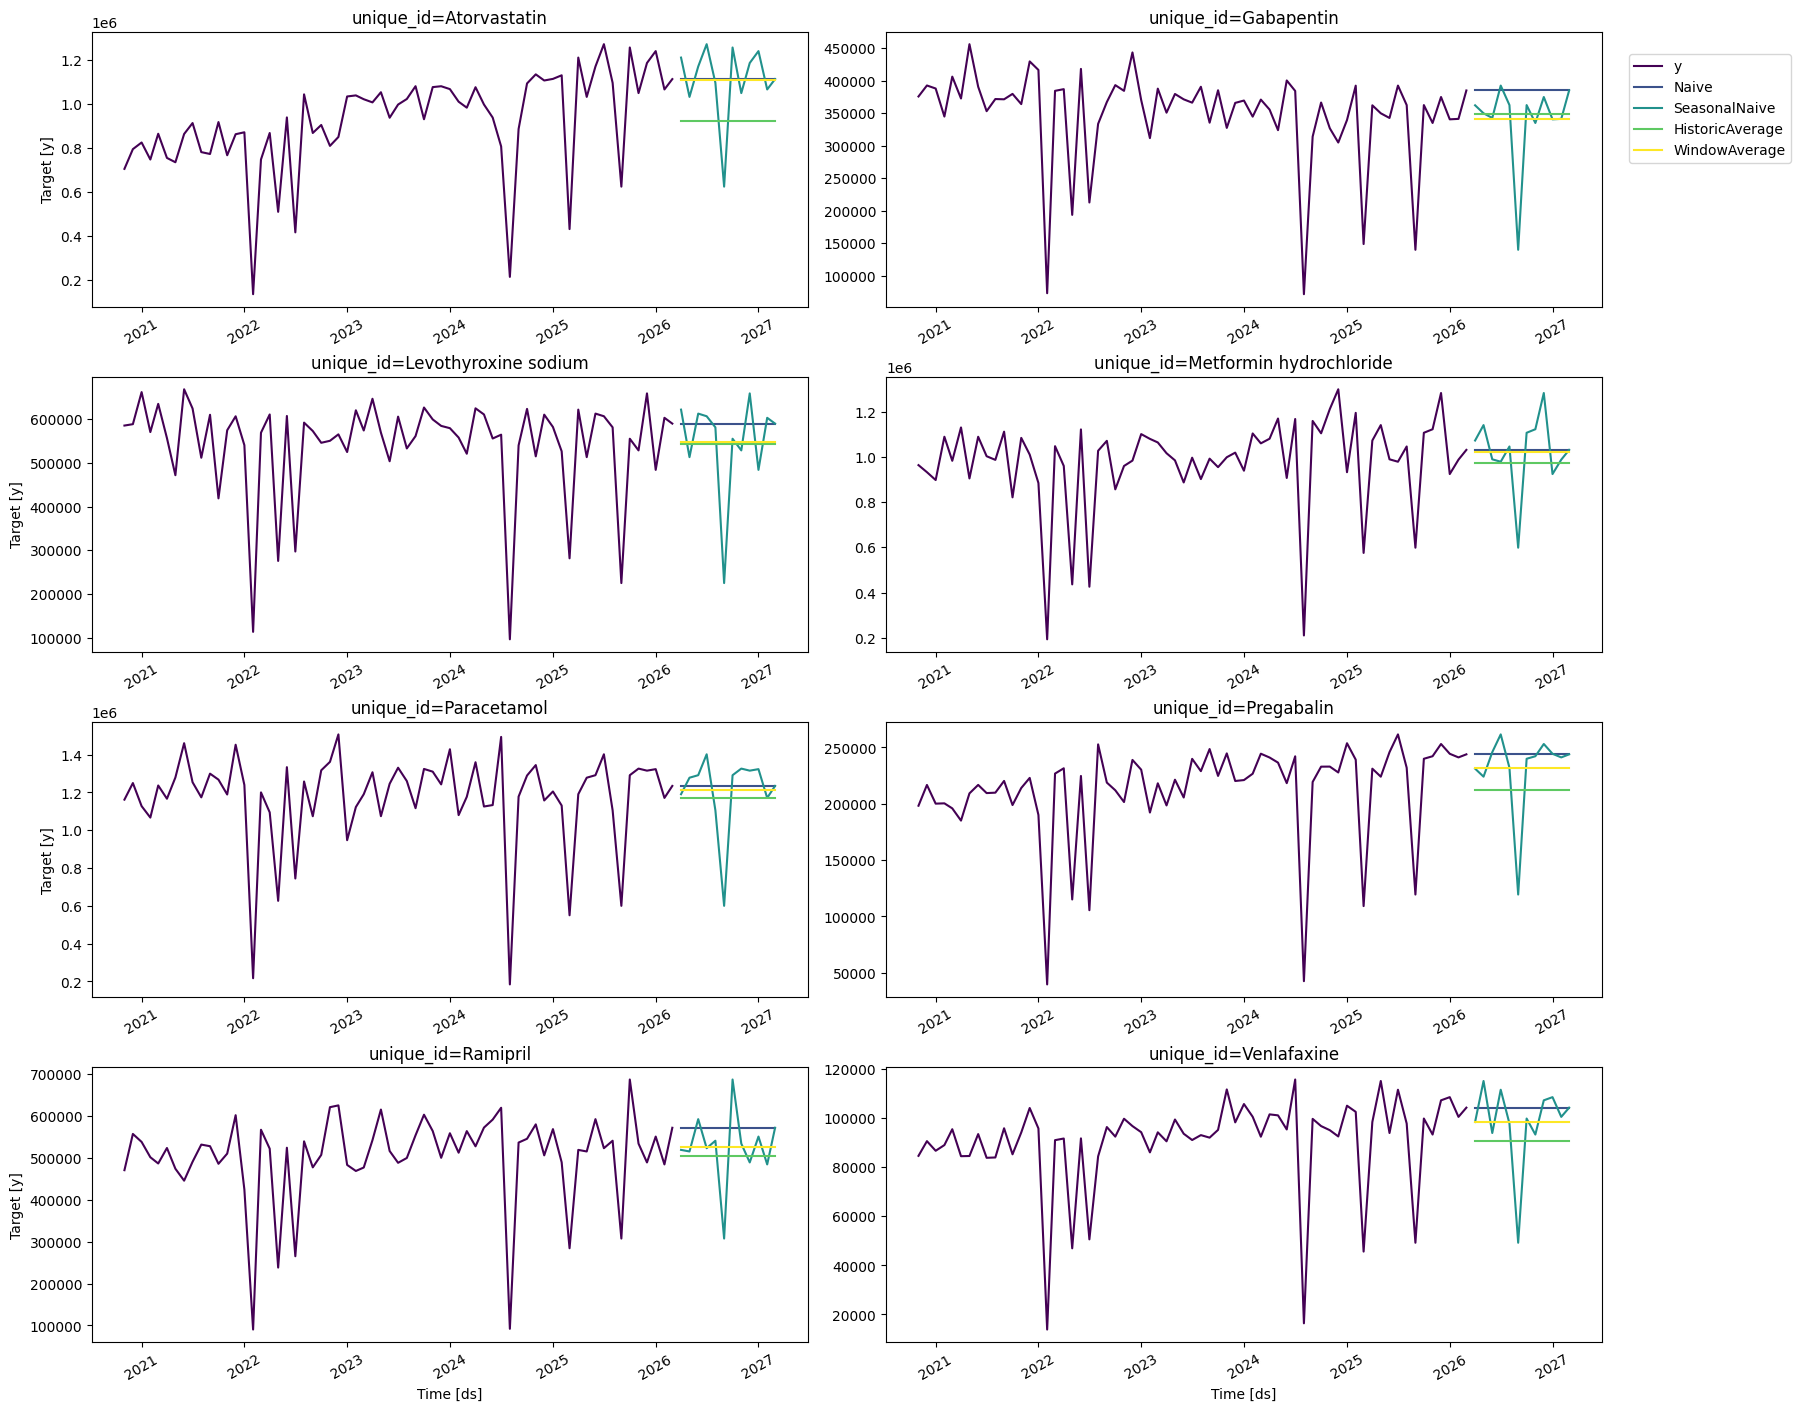

In [ ]:
plot_series(
    df=df,
    forecasts_df = preds,
    palette = "viridis"
)

In [ ]:
test = df.groupby("unique_id").tail(horizon)
train = df.drop(test.index).reset_index(drop=True)

In [ ]:
sf.fit(df=train)
preds = sf.predict(h=horizon)
eval_df = pd.merge(test, preds, "left", ["ds","unique_id"])

In [ ]:
evaluation = evaluate(
    eval_df,
    metrics=[mae, rmse, mape],
    models=["Naive", "SeasonalNaive", "HistoricAverage", "WindowAverage"]
)

evaluation.head()

,unique_id,metric,Naive,SeasonalNaive,HistoricAverage,WindowAverage
0,Atorvastatin,mae,679118.750000,267803.250000,274226.507862,246965.805556
1,Gabapentin,mae,193570.333333,77879.083333,32539.833333,58530.819444
2,Levothyroxine sodium,mae,276373.000000,134538.083333,76371.864780,89647.444444
3,Metformin hydrochloride,mae,447602.333333,206790.750000,126917.613208,110030.486111
4,Paracetamol,mae,660697.416667,257664.916667,150788.878931,197377.027778


In [ ]:
evaluation = evaluation.drop(["unique_id"],axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,SeasonalNaive,HistoricAverage,WindowAverage
0,mae,334295.531250,140376.812500,97368.530071,102908.454861
1,mape,0.504401,0.251737,0.177539,0.186405
2,rmse,349064.777687,211507.496492,122535.767096,123018.960702


In [ ]:
from prophet import Prophet
import pandas as pd

all_preds = []

for drug in train["unique_id"].unique():

    train_drug = train[train["unique_id"] == drug][["ds", "y"]]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(train_drug)

    future = model.make_future_dataframe(
        periods=horizon,
        freq="MS"
    )

    forecast = model.predict(future)

    preds = forecast[["ds", "yhat"]].tail(horizon)

    preds = preds.rename(columns={"yhat": "Prophet"})

    preds["unique_id"] = drug

    all_preds.append(preds)

Prophet_preds = pd.concat(all_preds, ignore_index=True)

23:55:21 - cmdstanpy - INFO - Chain [1] start processing
23:55:22 - cmdstanpy - INFO - Chain [1] done processing
23:55:22 - cmdstanpy - INFO - Chain [1] start processing
23:55:23 - cmdstanpy - INFO - Chain [1] done processing
23:55:24 - cmdstanpy - INFO - Chain [1] start processing
23:55:25 - cmdstanpy - INFO - Chain [1] done processing
23:55:25 - cmdstanpy - INFO - Chain [1] start processing
23:55:25 - cmdstanpy - INFO - Chain [1] done processing
23:55:26 - cmdstanpy - INFO - Chain [1] start processing
23:55:26 - cmdstanpy - INFO - Chain [1] done processing
23:55:27 - cmdstanpy - INFO - Chain [1] start processing
23:55:27 - cmdstanpy - INFO - Chain [1] done processing
23:55:28 - cmdstanpy - INFO - Chain [1] start processing
23:55:28 - cmdstanpy - INFO - Chain [1] done processing
23:55:28 - cmdstanpy - INFO - Chain [1] start processing
23:55:29 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
Prophet_eval = test.merge(
    Prophet_preds,
    on=["unique_id", "ds"],
    how="left"
)

Prophet_eval.head()

,ds,unique_id,y,Prophet
0,2025-04-01,Atorvastatin,1212302.0,1.086570e+06
1,2025-05-01,Atorvastatin,1033431.0,9.906009e+05
2,2025-06-01,Atorvastatin,1171707.0,1.087556e+06
3,2025-07-01,Atorvastatin,1273335.0,9.557805e+05
4,2025-08-01,Atorvastatin,1097261.0,8.097016e+05


In [ ]:
Prophet_metrics = evaluate(
    Prophet_eval,
    metrics=[mae, rmse, mape]
)

Prophet_metrics

,unique_id,metric,Prophet
0,Atorvastatin,mae,146105.114996
1,Gabapentin,mae,61721.507321
2,Levothyroxine sodium,mae,97527.732643
3,Metformin hydrochloride,mae,129388.777490
4,Paracetamol,mae,177105.466528
5,Pregabalin,mae,28419.498729
6,Ramipril,mae,73830.265685
7,Venlafaxine,mae,15103.807941
8,Atorvastatin,rmse,188906.890527
9,Gabapentin,rmse,81276.250058


In [ ]:
Prophet_mean_metrics = (
    Prophet_metrics
    .drop(["unique_id"], axis=1)
    .groupby("metric")
    .mean()
    .reset_index()
)

Prophet_mean_metrics

,metric,Prophet
0,mae,91150.271417
1,mape,0.186361
2,rmse,127038.998442


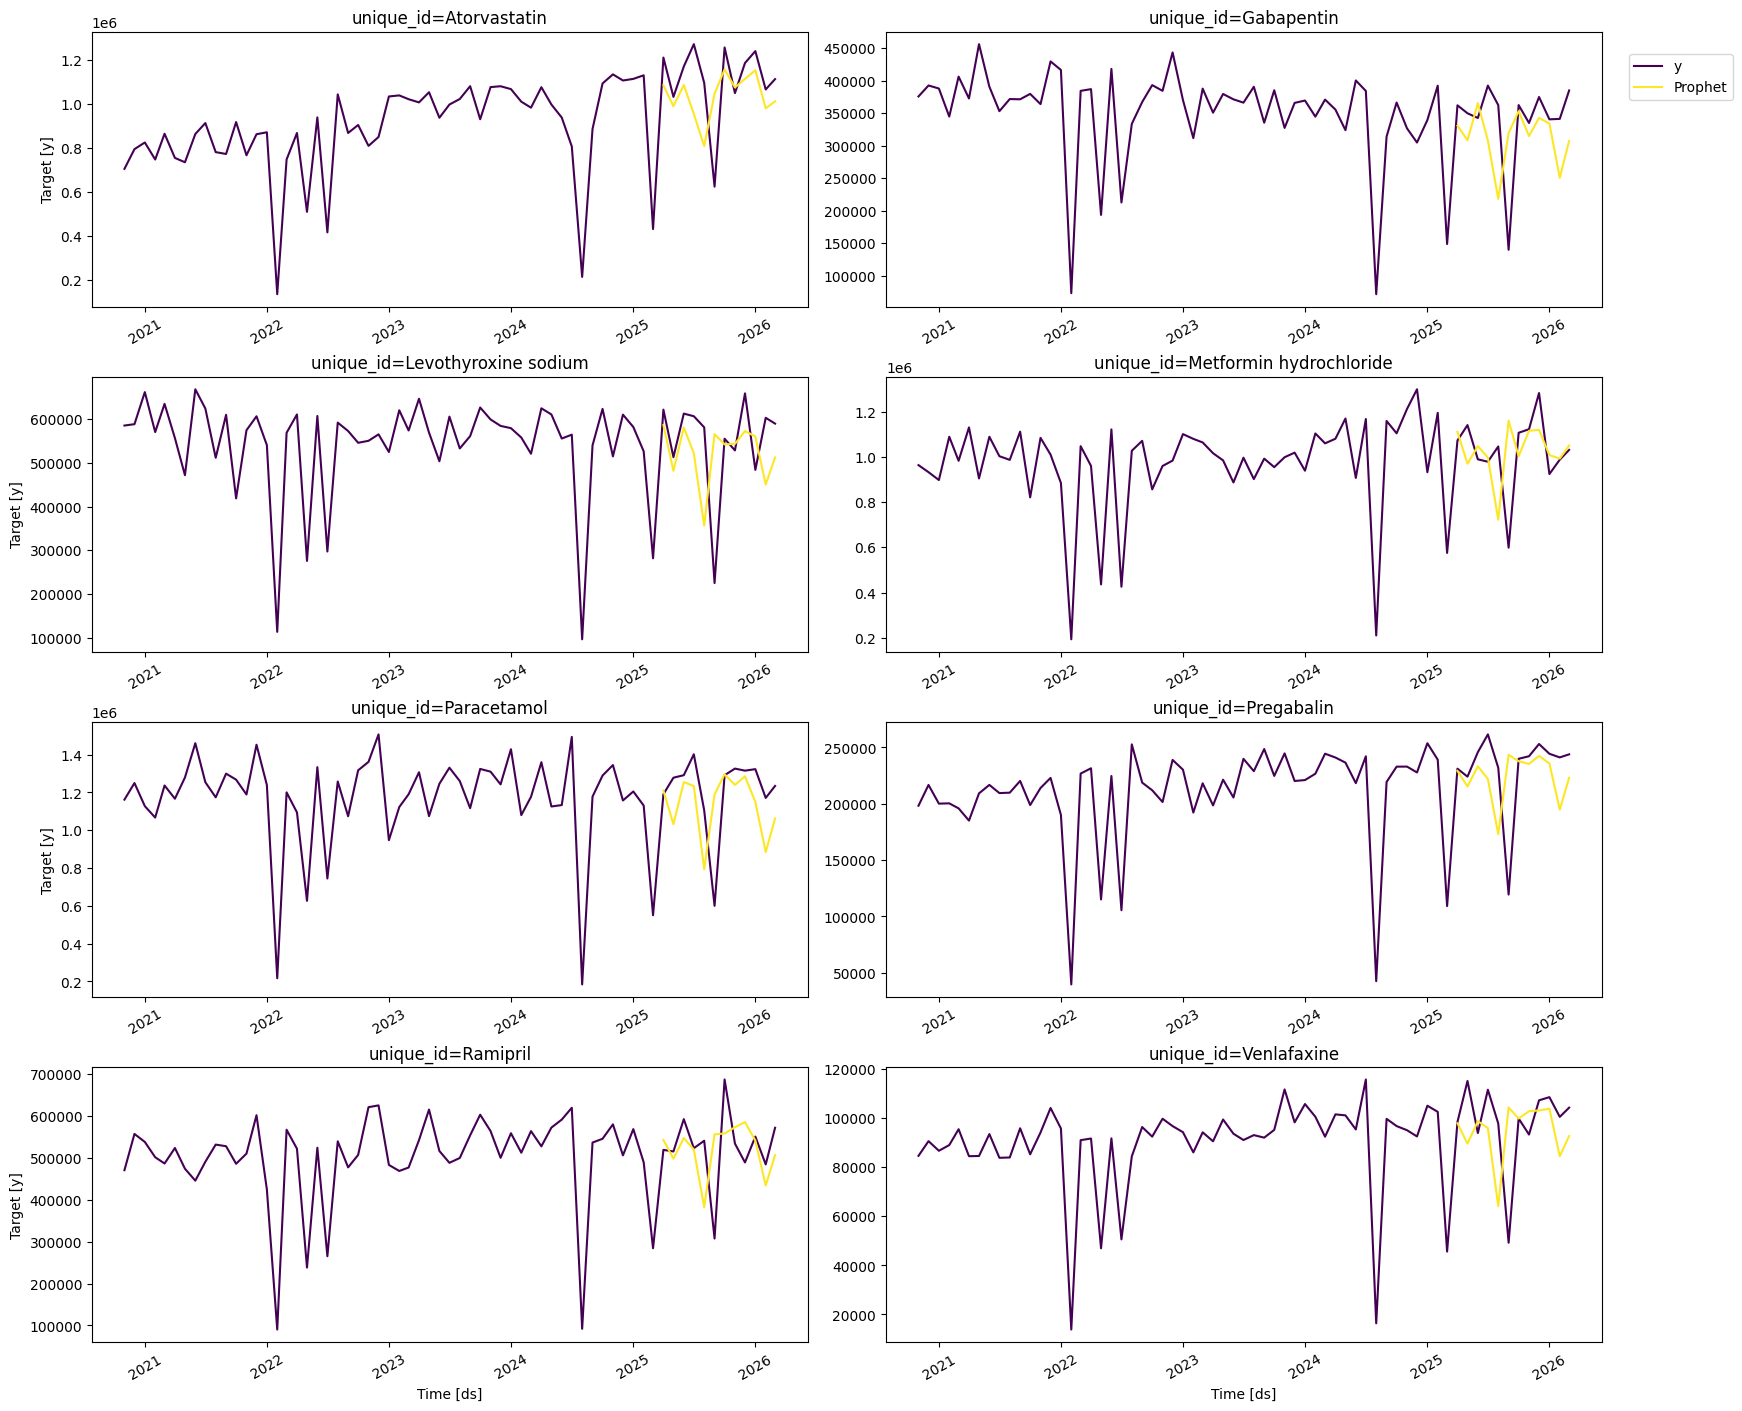

In [ ]:
plot_series(
    df=df,
    forecasts_df = Prophet_preds,
    palette = "viridis"
)

23:59:03 - cmdstanpy - INFO - Chain [1] start processing
23:59:04 - cmdstanpy - INFO - Chain [1] done processing


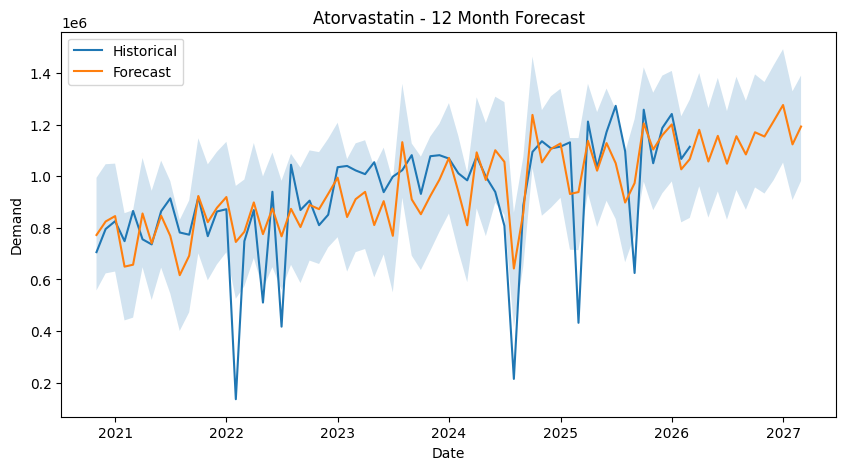

23:59:06 - cmdstanpy - INFO - Chain [1] start processing
23:59:07 - cmdstanpy - INFO - Chain [1] done processing


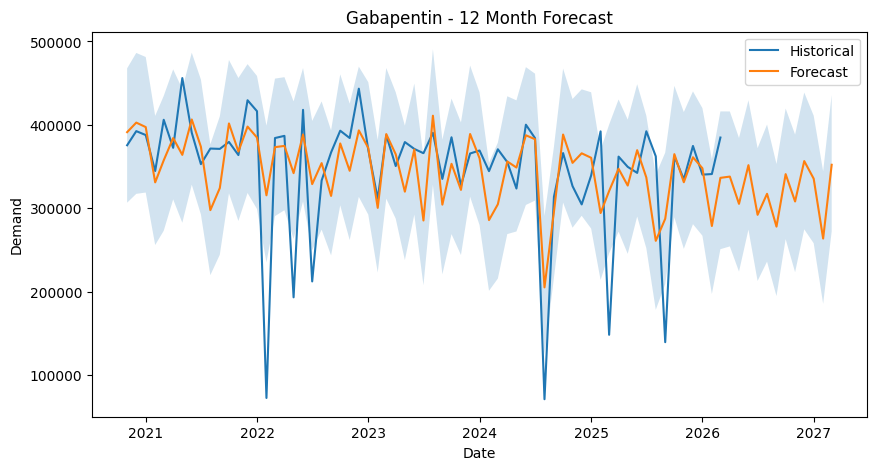

23:59:08 - cmdstanpy - INFO - Chain [1] start processing
23:59:09 - cmdstanpy - INFO - Chain [1] done processing


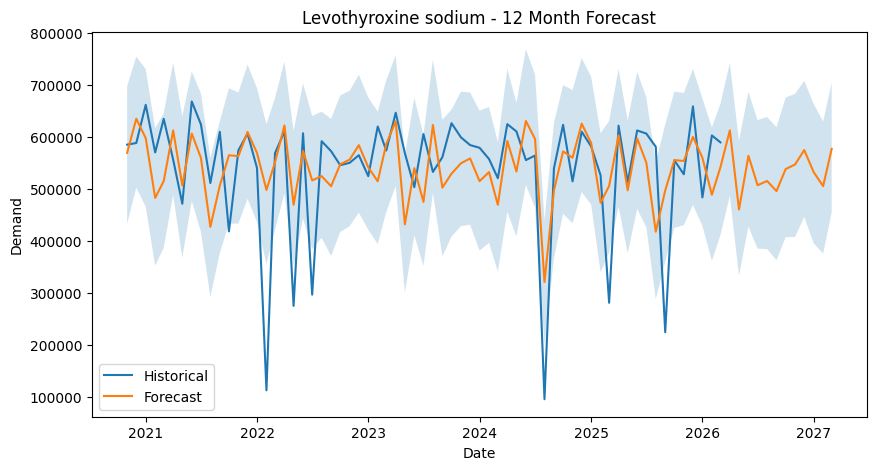

23:59:10 - cmdstanpy - INFO - Chain [1] start processing
23:59:11 - cmdstanpy - INFO - Chain [1] done processing


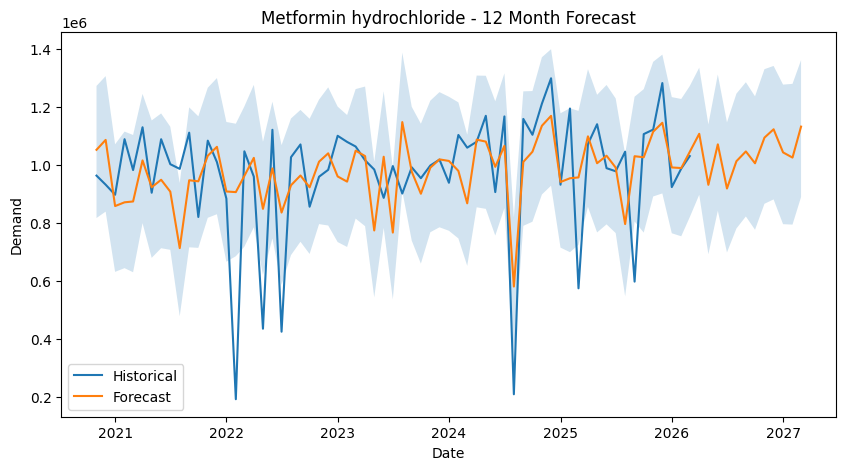

23:59:12 - cmdstanpy - INFO - Chain [1] start processing
23:59:13 - cmdstanpy - INFO - Chain [1] done processing


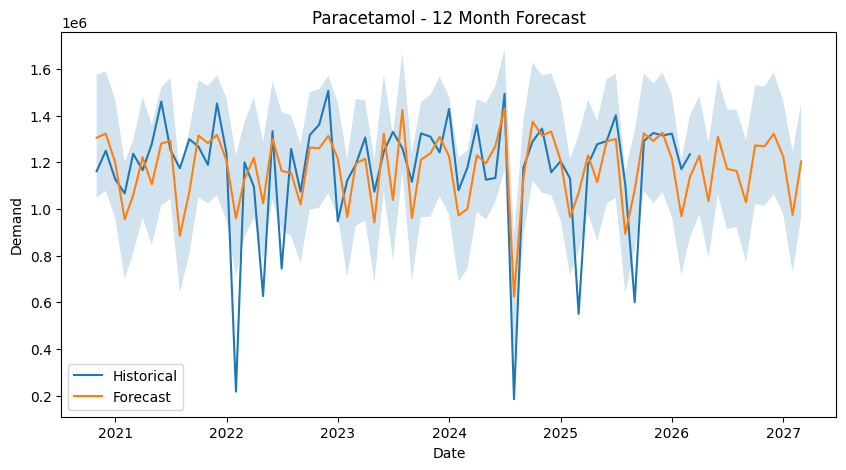

23:59:15 - cmdstanpy - INFO - Chain [1] start processing
23:59:16 - cmdstanpy - INFO - Chain [1] done processing


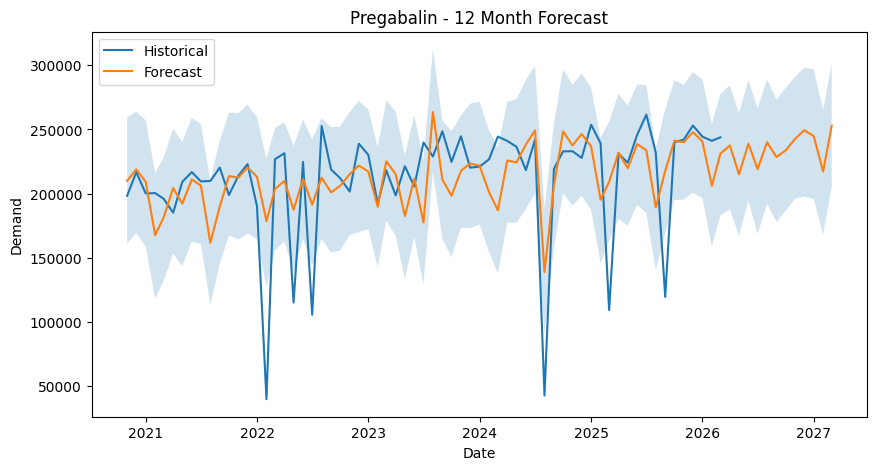

23:59:17 - cmdstanpy - INFO - Chain [1] start processing
23:59:18 - cmdstanpy - INFO - Chain [1] done processing


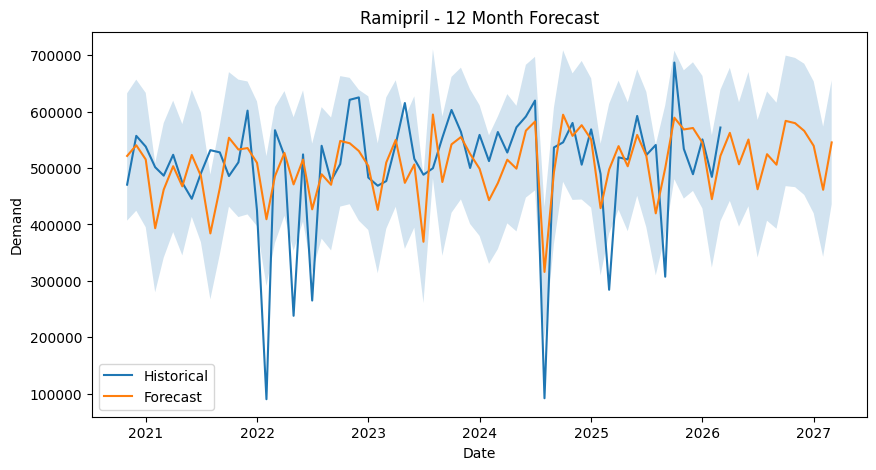

23:59:19 - cmdstanpy - INFO - Chain [1] start processing
23:59:19 - cmdstanpy - INFO - Chain [1] done processing


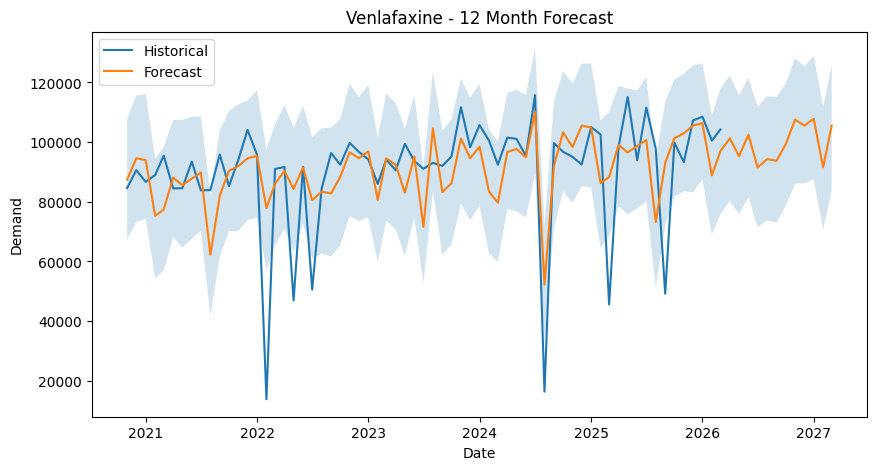

,unique_id,ds,yhat,yhat_lower,yhat_upper
0,Atorvastatin,2020-11-01,772472.202440,557565.895037,9.942124e+05
1,Atorvastatin,2020-12-01,824888.596048,623642.141335,1.046935e+06
2,Atorvastatin,2021-01-01,845757.858796,630717.968449,1.049272e+06
3,Atorvastatin,2021-02-01,649803.598418,441363.122400,8.570782e+05
4,Atorvastatin,2021-03-01,657338.952793,452018.627150,8.688427e+05


In [ ]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

all_forecasts = []

for drug in df["unique_id"].unique():

    # Prepare data for one drug
    drug_df = (
        df[df["unique_id"] == drug][["ds", "y"]]
        .sort_values("ds")
        .reset_index(drop=True)
    )

    # Fit Prophet
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(drug_df)

    # Forecast next 12 months
    future = model.make_future_dataframe(
        periods=12,
        freq="MS"
    )

    forecast = model.predict(future)

    # Store forecast
    forecast["unique_id"] = drug
    all_forecasts.append(
        forecast[
            [
                "unique_id",
                "ds",
                "yhat",
                "yhat_lower",
                "yhat_upper"
            ]
        ]
    )

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        drug_df["ds"],
        drug_df["y"],
        label="Historical"
    )

    ax.plot(
        forecast["ds"],
        forecast["yhat"],
        label="Forecast"
    )

    ax.fill_between(
        forecast["ds"],
        forecast["yhat_lower"],
        forecast["yhat_upper"],
        alpha=0.2
    )

    ax.set_title(f"{drug} - 12 Month Forecast")
    ax.set_xlabel("Date")
    ax.set_ylabel("Demand")
    ax.legend()

    plt.show()

# Combined forecast dataframe
future_forecasts = pd.concat(
    all_forecasts,
    ignore_index=True
)

future_forecasts.head()

In [ ]:
future_only = []

for drug in df["unique_id"].unique():

    drug_forecast = future_forecasts[
        future_forecasts["unique_id"] == drug
    ].tail(12)

    future_only.append(drug_forecast)

future_only = pd.concat(
    future_only,
    ignore_index=True
)

future_only

,unique_id,ds,yhat,yhat_lower,yhat_upper
0,Atorvastatin,2027-04-01,1.221340e+06,1.019907e+06,1.448124e+06
1,Atorvastatin,2027-05-01,1.092599e+06,8.882206e+05,1.311534e+06
2,Atorvastatin,2027-06-01,1.185325e+06,9.637938e+05,1.400471e+06
3,Atorvastatin,2027-07-01,1.050883e+06,8.379460e+05,1.270299e+06
4,Atorvastatin,2027-08-01,1.413992e+06,1.197570e+06,1.642038e+06
...,...,...,...,...,...
91,Venlafaxine,2027-11-01,1.121672e+05,9.125816e+04,1.329066e+05
92,Venlafaxine,2027-12-01,1.054953e+05,8.450426e+04,1.263981e+05
93,Venlafaxine,2028-01-01,1.093728e+05,8.951649e+04,1.296442e+05
94,Venlafaxine,2028-02-01,9.440024e+04,7.378735e+04,1.145930e+05
